In [1]:
import sys

if 'google.colab' in sys.modules:
  %pip install opencv-python


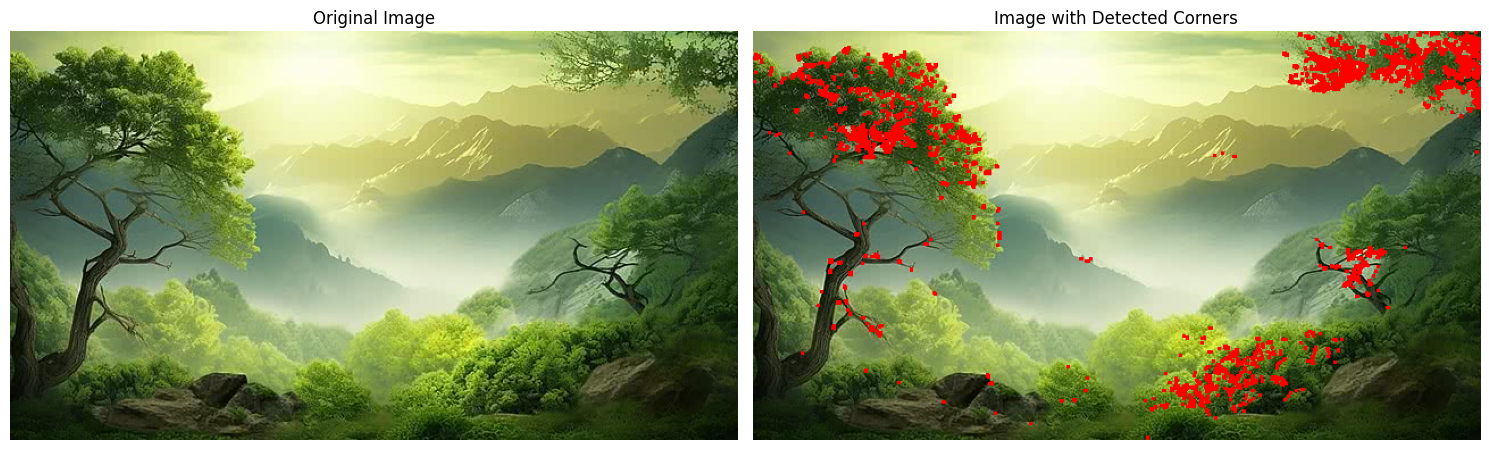

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image provided by the user
image_path = '/content/forest image.jpg'
img = cv2.imread(image_path)

# Check if the image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Create a copy of the original image for display purposes
    img_original_display = img.copy()

    # Convert to grayscale for corner detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Convert to float32 for Harris Corner Detector
    gray = np.float32(gray)

    # Apply Harris Corner Detector
    # Arguments: src, blockSize, ksize, k
    # blockSize: It is the size of neighbourhood considered for corner detection
    # ksize: Aperture parameter of Sobel derivative used.
    # k: Harris detector free parameter in the equation
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)

    # Result is dilated for marking the corners, not important
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image.
    # Marking the corners in red on the original image
    # Create a copy to draw on, otherwise, the original 'img' will be modified for subsequent uses
    img_corners = img.copy()
    img_corners[dst > 0.01 * dst.max()] = [0, 0, 255]

    # Display the results side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    axes[0].imshow(cv2.cvtColor(img_original_display, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Image with Detected Corners')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
